# Gemma 3 Text-to-SQL: LoRA Fine-Tuning with Open-RL

Fine-tune **Gemma 3 1B** (pre-trained) to generate SQL from natural language with parameter-efficient LoRA training through the Open-RL server.

This version of the notebook keeps the code intentionally explicit. The goal is to show the training flow clearly, not to compress everything into the fewest possible lines.

| | |
|---|---|
| **Model** | `google/gemma-3-1b-pt` |
| **Dataset** | [gretel-synthetic-text-to-sql](https://huggingface.co/datasets/philschmid/gretel-synthetic-text-to-sql) (100k examples) |
| **Method** | LoRA SFT, rank 16, MLP + attention, base frozen |
| **Infra** | [Open-RL](https://github.com/gke-labs/open-rl) server + [Tinker SDK](https://pypi.org/project/tinker/) client |

## Prerequisites

Before running this notebook, you need:

**1. Client dependencies**
```bash
cd client && uv sync
```

**2. A running Open-RL server** in a separate terminal

| Hardware | Command |
|---|---|
| CPU (local dev) | `make run-text-to-sql-server` |
**3. Hugging Face access** to `google/gemma-3-1b-pt`. Run `huggingface-cli login` if needed.

In [52]:
import json
import os
import random
from pprint import pprint
import re
from dataclasses import asdict, dataclass
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import tinker
from datasets import load_dataset
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from tinker import types

os.environ.setdefault("TINKER_API_KEY", "tml-dummy-key")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Config

In [53]:

BASE_MODEL = "google/gemma-3-1b-pt"
TOKENIZER_MODEL = "google/gemma-3-1b-it"
DATASET_NAME = "philschmid/gretel-synthetic-text-to-sql"
MAX_SEQ_LENGTH = 512
EVAL_MAX_TOKENS = 256
RAW_DATASET_LIMIT = 12_500
EVAL_SPLIT_SIZE = 2_500


@dataclass
class Config:
    base_url: str = os.getenv("TINKER_BASE_URL") or os.getenv("OPEN_RL_BASE_URL") or "http://127.0.0.1:9003"
    steps: int = 50
    batch_size: int = 8
    lora_rank: int = 16
    learning_rate: float = 2e-4
    grad_clip_norm: float = 0.3
    eval_every: int = 125
    train_limit: int = 10_000
    eval_limit: int = 6
    seed: int = 30


config = Config()

config_table = pd.DataFrame.from_dict(asdict(config), orient="index", columns=["value"])
display(config_table)


,value
base_url,http://127.0.0.1:9003
steps,50
batch_size,8
lora_rank,16
learning_rate,0.0002
grad_clip_norm,0.3
eval_every,125
train_limit,10000
eval_limit,6
seed,30


In [54]:
async def get_server_model(service_client):
    try:
        capabilities = await service_client.get_server_capabilities_async()
    except Exception as exc:
        message = (
            f"Open-RL server at {config.base_url} is not reachable. "
            "Start it with `make run-text-to-sql-server`."
        )
        raise RuntimeError(message) from exc

    for model in capabilities.supported_models:
        model_name = getattr(model, "model_name", None)
        if model_name:
            return model_name

    return None


client = tinker.ServiceClient(
    api_key=os.getenv("TINKER_API_KEY", "tml-dummy-key"),
    base_url=config.base_url,
)

server_model = await get_server_model(client)
if server_model is None:
    raise RuntimeError(
        f"Server at {config.base_url} is reachable, but no model is loaded. "
        "Start it with `make run-text-to-sql-server`."
    )

print(f"Connected to {config.base_url}")
print(f"Server model: {server_model}")

Connected to http://127.0.0.1:9003
Server model: google/gemma-3-1b-pt


## Load and Preview data

In [55]:

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_MODEL)

dataset = load_dataset(DATASET_NAME, split="train")
dataset = dataset.shuffle(seed=config.seed)
dataset = dataset.select(range(min(RAW_DATASET_LIMIT, len(dataset))))
split = dataset.train_test_split(test_size=min(EVAL_SPLIT_SIZE, len(dataset) - 1), shuffle=False)

print(f"Dataset loaded: {len(dataset):,} rows")
print(f"Training split: {len(split['train']):,} rows")
print(f"Eval split: {len(split['test']):,} rows")

preview_rows = []
for row in split["train"].select(range(5)):
    preview_rows.append(
        {
            "Question": row["sql_prompt"],
            "Schema": row["sql_context"],
            "Target SQL": row["sql"],
        }
    )


for p in preview_rows:
    print(f"Question: {p['Question']}")
    print(f"Schema: {p['Schema']}")
    print(f"Target SQL: {p['Target SQL']}")


Dataset loaded: 12,500 rows
Training split: 10,000 rows
Eval split: 2,500 rows
Question: What is the number of Shariah-compliant financial institutions in Southeast Asia?
Schema: CREATE TABLE financial_institutions (institution_name TEXT, shariah_compliant BOOLEAN, region TEXT); INSERT INTO financial_institutions (institution_name, shariah_compliant, region) VALUES ('Bank Islam Brunei Darussalam', TRUE, 'Southeast Asia'); INSERT INTO financial_institutions (institution_name, shariah_compliant, region) VALUES ('Maybank Islamic Berhad', TRUE, 'Southeast Asia');
Target SQL: SELECT COUNT(institution_name) FROM financial_institutions WHERE shariah_compliant = TRUE AND region = 'Southeast Asia';
Question: Count the number of agricultural innovation patents by year in the 'innovation_patents' table, filtered to show only patents from African countries?
Schema: CREATE TABLE innovation_patents (id INT, title VARCHAR(200), year INT, country VARCHAR(50));
Target SQL: SELECT year, COUNT(*) FROM in

### Tokenize into Training Examples

Each example uses the Gemma instruct chat template. Prompt tokens get weight `0` and target SQL tokens get weight `1`, so the loss is only applied to the completion.

In [56]:

PROMPT_TEMPLATE = """Given the <USER_QUERY> and the <SCHEMA>, generate the corresponding SQL command to retrieve the desired data, considering the query's syntax, semantics, and schema constraints.

<SCHEMA>
{context}
</SCHEMA>

<USER_QUERY>
{question}
</USER_QUERY>
"""


def build_messages(sample):
    return [
        {
            "role": "user",
            "content": PROMPT_TEMPLATE.format(
                question=sample["sql_prompt"],
                context=sample["sql_context"],
            ),
        },
        {
            "role": "assistant",
            "content": sample["sql"],
        },
    ]


def make_datum(token_ids, weights):
    return types.Datum(
        model_input=types.ModelInput.from_ints(tokens=token_ids[:-1]),
        loss_fn_inputs={
            "weights": weights[1:],
            "target_tokens": token_ids[1:],
        },
    )


def build_example(sample):
    messages = build_messages(sample)

    prompt_text = tokenizer.apply_chat_template(
        messages[:1],
        tokenize=False,
        add_generation_prompt=True,
    )
    full_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    prompt_token_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    full_token_ids = tokenizer.encode(full_text, add_special_tokens=False)

    if len(full_token_ids) <= len(prompt_token_ids):
        return None
    if len(full_token_ids) > MAX_SEQ_LENGTH:
        return None

    target_token_count = len(full_token_ids) - len(prompt_token_ids)
    weights = [0] * len(prompt_token_ids) + [1] * target_token_count

    return {
        "messages" : messages,
        "question": sample["sql_prompt"],
        "target": sample["sql"],
        "prompt_tokens": prompt_token_ids,
        "active_tokens": target_token_count,
        "datum": make_datum(full_token_ids, weights),
    }


def build_examples(dataset_split, limit):
    examples = []
    limited_split = dataset_split.select(range(min(limit, len(dataset_split))))

    for row in limited_split:
        example = build_example(row)
        if example is not None:
            examples.append(example)

    return examples


train_examples = build_examples(split["train"], config.train_limit)
eval_examples = build_examples(split["test"], config.eval_limit)

if not train_examples:
    raise RuntimeError("No training examples fit within MAX_SEQ_LENGTH.")

batch_size = min(config.batch_size, len(train_examples))
batches_per_epoch = (len(train_examples) + batch_size - 1) // batch_size

examples_message = eval_examples[0]["messages"]

pprint(examples_message)
print(f"Usable training examples: {len(train_examples):,}")
print(f"Usable eval examples: {len(eval_examples):,}")
print(f"Batch size: {batch_size}")
print(f"Approximate batches per epoch: {batches_per_epoch:,}")


[{'content': 'Given the <USER_QUERY> and the <SCHEMA>, generate the '
             'corresponding SQL command to retrieve the desired data, '
             "considering the query's syntax, semantics, and schema "
             'constraints.\n'
             '\n'
             '<SCHEMA>\n'
             'CREATE TABLE Mediterranean_Marine_Species (species_name TEXT, '
             'population INT); INSERT INTO Mediterranean_Marine_Species '
             "(species_name, population) VALUES ('Dolphin', 35000), "
             "('Swordfish', 15000), ('Tuna', 22000);\n"
             '</SCHEMA>\n'
             '\n'
             '<USER_QUERY>\n'
             'What is the average population of marine species in the '
             'Mediterranean Sea?\n'
             '</USER_QUERY>\n',
  'role': 'user'},
 {'content': 'SELECT AVG(population) FROM Mediterranean_Marine_Species;',
  'role': 'assistant'}]
Usable training examples: 9,987
Usable eval examples: 5
Batch size: 8
Approximate batches per epoch: 1,2

## We can make a trainer with the tinker clinet along with a LoRA adapter

Evaluation sends all prompts to the current adapter, then computes exact match and sequence similarity against the target SQL.

In [57]:

trainer = await client.create_lora_training_client_async(
    base_model=BASE_MODEL,
    rank=config.lora_rank,
    train_mlp=True,
    train_attn=True,
    train_unembed=False,
)

print(f"Created LoRA adapter with rank {config.lora_rank}")

def normalize_sql(text):
    text = re.sub(r"<think>.*?</think>", " ", text, flags=re.DOTALL)
    text = text.replace("<|im_start|>", " ")
    text = text.replace("<|im_end|>", " ")
    text = text.strip()

    prefixes_to_strip = [
        r"^assistant\s*[:\-]?\s*",
        r"^sql\s*[:\-]?\s*",
        r"^```(?:sql)?\s*",
    ]
    for pattern in prefixes_to_strip:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)

    text = re.sub(r"\s*```$", "", text)
    text = " ".join(text.split()).lower()
    text = re.sub(r"\s+([,;()])", r"\1", text)
    text = re.sub(r"([,(])\s+", r"\1", text)
    return text


def create_sampler(alias):
    weights_path = trainer.save_weights_for_sampler(name=alias).result().path
    return client.create_sampling_client(weights_path)


def decode_first_sequence(result):
    if result.sequences:
        token_ids = result.sequences[0].tokens
    else:
        token_ids = []
    return tokenizer.decode(token_ids, skip_special_tokens=True)


def run_eval(alias, examples):
    sampler = create_sampler(alias)
    pending_requests = []

    for example in examples:
        future = sampler.sample(
            prompt=types.ModelInput.from_ints(tokens=example["prompt_tokens"]),
            num_samples=1,
            sampling_params=types.SamplingParams(
                max_tokens=EVAL_MAX_TOKENS,
                temperature=0.0,
            ),
        )
        pending_requests.append((example, future))

    rows = []
    exact_match_count = 0
    similarity_sum = 0.0

    for example, future in pending_requests:
        result = future.result()
        predicted_sql = normalize_sql(decode_first_sequence(result))
        target_sql = normalize_sql(example["target"])
        similarity = SequenceMatcher(None, predicted_sql, target_sql).ratio()
        exact_match = predicted_sql == target_sql

        if exact_match:
            exact_match_count += 1
        similarity_sum += similarity

        rows.append(
            {
                "question": example["question"],
                "predicted": predicted_sql,
                "target": target_sql,
                "exact": exact_match,
                "similarity": similarity,
            }
        )

    details_df = pd.DataFrame(rows)
    row_count = max(1, len(rows))
    exact_match_rate = exact_match_count / row_count
    average_similarity = similarity_sum / row_count

    return exact_match_rate, average_similarity, details_df

Created LoRA adapter with rank 16


## Baseline Before Training

In [58]:
before_exact, before_similarity, baseline_df = run_eval("baseline", eval_examples)

print(f"Baseline exact match: {before_exact * 100:.1f}%")
print(f"Baseline similarity: {before_similarity * 100:.1f}%")

display(baseline_df.head(8))

Baseline exact match: 0.0%
Baseline similarity: 15.2%


,question,predicted,target,exact,similarity
0,What is the average population of marine speci...,"given the <user_query> and the <schema>,genera...",select avg(population) from mediterranean_mari...,False,0.087935
1,Identify the top 3 most popular sustainable br...,"given the <user_query> and the <schema>,genera...","select brand_name,is_sustainable,sum(revenue) ...",False,0.173348
2,What is the average rating of hotels in 'Asia'...,"given the <user_query> and the <schema>,genera...",select avg(rating) from hotels where region = ...,False,0.078091
3,Insert a new space mission record for the 'Apo...,"given the <user_query> and the <schema>,genera...","insert into spacemissions(missionid,missionnam...",False,0.197556
4,What is the current landfill capacity in cubic...,"given the <user_query> and the <schema>,genera...",select capacity_cubic_meters from landfill_cap...,False,0.220716


## Train

Each step sends a batch to the Open-RL server for forward/backward and an Adam update. All model compute stays on the server side.

In [59]:
metrics_path = Path("artifacts/texttosql_notebook_metrics.jsonl")
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text("", encoding="utf-8")

metrics_log = []


def record_metric(step, phase, loss=None, exact_match=None, similarity=None):
    row = {"step": step, "phase": phase}
    if loss is not None:
        row["loss"] = loss
    if exact_match is not None:
        row["exact_match"] = exact_match
    if similarity is not None:
        row["similarity"] = similarity

    metrics_log.append(row)
    with metrics_path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(row) + "\n")


record_metric(step=0, phase="eval", exact_match=before_exact, similarity=before_similarity)
print(f"Metrics will be written to {metrics_path}")

Metrics will be written to artifacts/texttosql_notebook_metrics.jsonl


## Training Loop

In [60]:
losses = []
eval_history = [
    {
        "step": 0,
        "exact_match": before_exact,
        "similarity": before_similarity,
    }
]

rng = random.Random(config.seed)
shuffled_indices = list(range(len(train_examples)))
rng.shuffle(shuffled_indices)
position = 0

progress_bar = tqdm(range(1, config.steps + 1), desc="Training", unit="step")

for step in progress_bar:
    if position + batch_size > len(shuffled_indices):
        rng.shuffle(shuffled_indices)
        position = 0

    batch_indices = shuffled_indices[position:position + batch_size]
    position += batch_size

    batch = []
    for index in batch_indices:
        batch.append(train_examples[index])

    datums = []
    active_token_count = 0
    for example in batch:
        datums.append(example["datum"])
        active_token_count += example["active_tokens"]

    forward_backward_future = await trainer.forward_backward_async(datums, "cross_entropy")
    optimizer_future = await trainer.optim_step_async(
        types.AdamParams(
            learning_rate=config.learning_rate,
            grad_clip_norm=config.grad_clip_norm,
        )
    )

    forward_backward_result = await forward_backward_future
    await optimizer_future

    loss_sum = float(forward_backward_result.metrics.get("loss:sum", 0.0))
    loss = loss_sum / max(1, active_token_count)
    losses.append(loss)
    record_metric(step=step, phase="train", loss=loss)
    progress_bar.set_postfix(loss=f"{loss:.4f}")

    should_evaluate = step % config.eval_every == 0 or step == config.steps
    if should_evaluate:
        exact_match, similarity, _ = run_eval(f"step_{step}", eval_examples)
        eval_history.append(
            {
                "step": step,
                "exact_match": exact_match,
                "similarity": similarity,
            }
        )
        record_metric(
            step=step,
            phase="eval",
            exact_match=exact_match,
            similarity=similarity,
        )
        progress_bar.write(
            f"[eval at step {step}] exact={exact_match * 100:.1f}% similarity={similarity * 100:.1f}%"
        )

Training: 100%|██████████| 50/50 [02:52<00:00,  3.46s/step, loss=0.3424]

[eval at step 50] exact=60.0% similarity=88.2%


## Results

In [61]:
eval_df = pd.DataFrame(eval_history)
eval_plot_df = eval_df.copy()
eval_plot_df["exact_match"] = eval_plot_df["exact_match"] * 100
eval_plot_df["similarity"] = eval_plot_df["similarity"] * 100

initial_loss = losses[0]
final_loss = losses[-1]
loss_drop_percent = (initial_loss - final_loss) / (abs(initial_loss) or 1.0) * 100

summary_rows = [
    {
        "Metric": "Exact Match (%)",
        "Before": f"{before_exact * 100:.1f}",
        "After": f"{eval_history[-1]['exact_match'] * 100:.1f}",
    },
    {
        "Metric": "Similarity (%)",
        "Before": f"{before_similarity * 100:.1f}",
        "After": f"{eval_history[-1]['similarity'] * 100:.1f}",
    },
    {
        "Metric": "Loss",
        "Before": f"{initial_loss:.4f}",
        "After": f"{final_loss:.4f}",
    },
    {
        "Metric": "Loss Drop (%)",
        "Before": "-",
        "After": f"{loss_drop_percent:.1f}",
    },
]

summary_df = pd.DataFrame(summary_rows).set_index("Metric")
display(summary_df)

,Before,After
Metric,,
Exact Match (%),0.0,60.0
Similarity (%),15.2,88.2
Loss,1.3572,0.3424
Loss Drop (%),-,74.8


Baseline exact match: 0.0%  Finetuned exact match: 60.0%


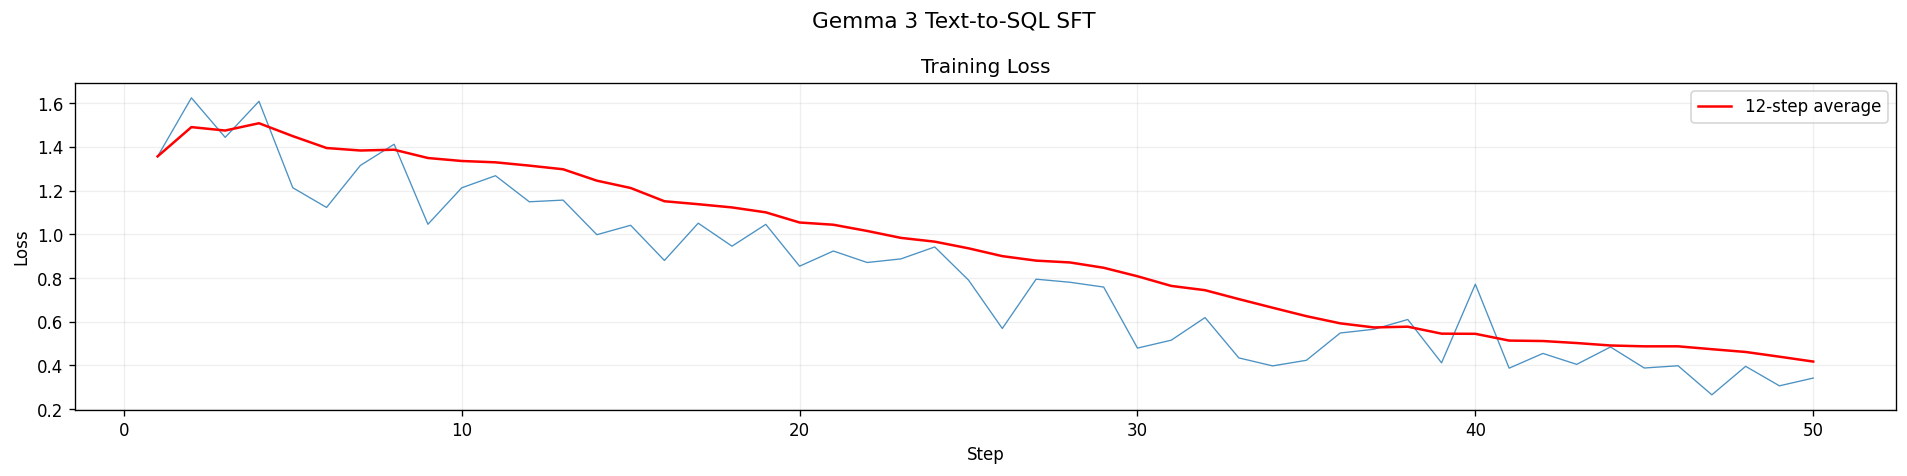

Saved plot to artifacts/texttosql_notebook_results.png


In [62]:
fig, ax = plt.subplots(figsize=(16, 4))

loss_steps = list(range(1, len(losses) + 1))
ax.plot(loss_steps, losses, linewidth=0.8, alpha=0.8)
if len(losses) > 1:
    smoothing_window = min(25, max(1, len(losses) // 4))
    smoothed_loss = pd.Series(losses).rolling(smoothing_window, min_periods=1).mean()
    ax.plot(
        loss_steps,
        smoothed_loss,
        color="red",
        linewidth=1.5,
        label=f"{smoothing_window}-step average",
    )
    ax.legend()
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss")
ax.grid(alpha=0.2)

# Print first and last accuracy (exact match) if available
if eval_history and isinstance(eval_history, list) and "exact_match" in eval_history[0]:
    first_acc = eval_history[0].get("exact_match", None)
    last_acc = eval_history[-1].get("exact_match", None)
    if first_acc is not None and last_acc is not None:
        print(f"Baseline exact match: {first_acc * 100:.1f}%  Finetuned exact match: {last_acc * 100:.1f}%")
    else:
        print("Accuracy history not available")
else:
    print("Accuracy history not available")

fig.suptitle("Gemma 3 Text-to-SQL SFT", fontsize=13)
plt.tight_layout()

plot_path = Path("artifacts/texttosql_notebook_results.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path}")

### Sample Predictions After Training

In [63]:
_, _, after_training_df = run_eval("final", eval_examples)
display(after_training_df.head(10))

,question,predicted,target,exact,similarity
0,What is the average population of marine speci...,select avg(population) from mediterranean_mari...,select avg(population) from mediterranean_mari...,True,1.000000
1,Identify the top 3 most popular sustainable br...,"select brand_name,sum(revenue) as revenue from...","select brand_name,is_sustainable,sum(revenue) ...",False,0.759184
2,What is the average rating of hotels in 'Asia'...,select avg(rating) from hotels where region = ...,select avg(rating) from hotels where region = ...,True,1.000000
3,Insert a new space mission record for the 'Apo...,"insert into spacemissions(missionid,missionnam...","insert into spacemissions(missionid,missionnam...",True,1.000000
4,What is the current landfill capacity in cubic...,"select city,capacity_cubic_meters from landfil...",select capacity_cubic_meters from landfill_cap...,False,0.652174


## Try It Yourself

Query the fine-tuned model with your own schema and question.

In [64]:
def build_user_prompt(question, schema):
    return PROMPT_TEMPLATE.format(question=question, context=schema)


def generate_sql(question, schema, sampler_name="interactive"):
    prompt_text = tokenizer.apply_chat_template(
        [{"role": "user", "content": build_user_prompt(question, schema)}],
        tokenize=False,
        add_generation_prompt=True,
    )
    prompt_token_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    sampler = create_sampler(sampler_name)

    result = sampler.sample(
        prompt=types.ModelInput.from_ints(tokens=prompt_token_ids),
        num_samples=1,
        sampling_params=types.SamplingParams(
            max_tokens=EVAL_MAX_TOKENS,
            temperature=0.0,
        ),
    ).result()

    return decode_first_sequence(result).strip()

In [65]:
schema = """
CREATE TABLE employees (
    id INT PRIMARY KEY,
    name VARCHAR(100),
    department VARCHAR(50),
    salary DECIMAL(10,2),
    hire_date DATE
);
""".strip()

questions = [
    "What are the names and salaries of employees in the Engineering department, ordered by salary descending?",
    "How many employees were hired after 2023-01-01?",
    "What is the average salary by department?",
]

generated_rows = []
for question in questions:
    generated_rows.append(
        {
            "Question": question,
            "Generated SQL": generate_sql(question, schema),
        }
    )

print(schema)
display(pd.DataFrame(generated_rows))

CREATE TABLE employees (
    id INT PRIMARY KEY,
    name VARCHAR(100),
    department VARCHAR(50),
    salary DECIMAL(10,2),
    hire_date DATE
);


,Question,Generated SQL
0,What are the names and salaries of employees i...,"SELECT name, salary FROM employees WHERE depar..."
1,How many employees were hired after 2023-01-01?,SELECT COUNT(*) FROM employees WHERE hire_date...
2,What is the average salary by department?,SELECT AVG(salary) FROM employees WHERE depart...


## Next Steps

| Idea | How |
|---|---|
| Train longer | Increase `config.steps` to 800 or more |
| Sweep hyperparameters | Try different `lora_rank`, `learning_rate`, and `batch_size` values |
| Run faster on GPU | Use `make run-text-to-sql-server-gpu` |
| Run headless | `make run-text-to-sql-sft TEXT_TO_SQL_PRESET=notebook` |
| Plot saved metrics | `make plot-metrics FILE=client/artifacts/texttosql_notebook_metrics.jsonl` |